(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

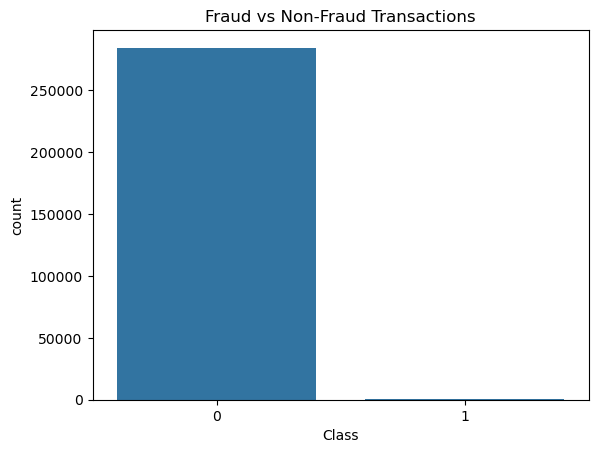

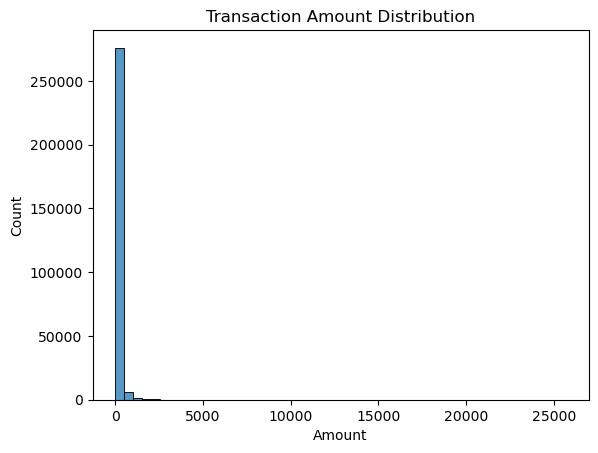

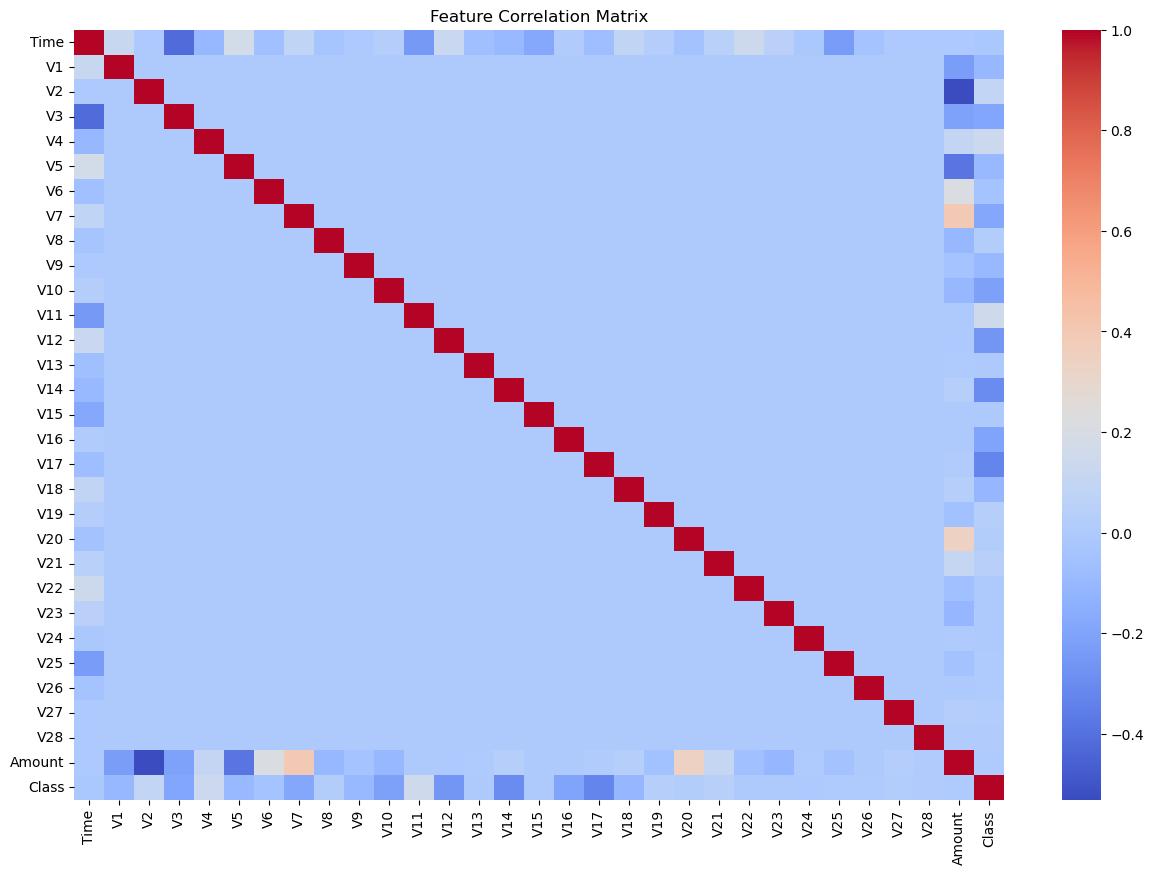

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv("creditcard.csv")

# Basic Information
print(df.shape)
print(df.info())
print(df.describe())

# Missing Values
print(df.isnull().sum())

# Fraud Distribution
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

# Amount Distribution
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

# Correlation Matrix
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Feature Scaling
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

# Split Features and Target
X = df.drop('Class', axis=1)
y = df['Class']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# SVM
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_smote, y_train_smote)
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:,1]

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# GridSearchCV - Random Forest
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(X_train_smote, y_train_smote)
print(grid_rf.best_params_)

# GridSearchCV - XGBoost
xgb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5,7]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_smote, y_train_smote)
print(grid_xgb.best_params_)

# Evaluation Function
def evaluate_model(name, y_test, y_pred, y_prob):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return [name, accuracy, precision, recall, f1, roc_auc]

results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
results.append(evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb))

comparison = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC AUC"]
)

print(comparison)

# Confusion Matrix Function
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")

    plt.show()

plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
plot_confusion_matrix(y_test, y_pred_svm, "SVM")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost")

# Classification Reports
print(classification_report(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_xgb))

# ROC Curves
plt.figure(figsize=(10,8))

for probs, label in [
    (y_prob_lr,'Logistic Regression'),
    (y_prob_svm,'SVM'),
    (y_prob_rf,'Random Forest'),
    (y_prob_xgb,'XGBoost')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=label)

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(15))

sns.barplot(x='Importance', y='Feature', data=importance.head(15))
plt.title("Top 15 Important Features")
plt.show()

# Final Ranking
comparison = comparison.sort_values(by='F1 Score', ascending=False)

sns.barplot(x='F1 Score', y='Model', data=comparison)
plt.title("Model Comparison by F1 Score")
plt.show()
